
# Synthetic Privacy-Preserving Medical Dataset Generator



In [1]:
# ── Step 1: Install ───────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "-q", "faker", "imbalanced-learn", "shap", "xgboost"], check=True)

CompletedProcess(args=['pip', 'install', '-q', 'faker', 'imbalanced-learn', 'shap', 'xgboost'], returncode=0)

In [2]:
# ── Imports ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import json, uuid, warnings
import matplotlib.pyplot as plt
import shap

from faker import Faker
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)
fake = Faker()
Faker.seed(42)
print("✅ Libraries loaded.\n")


✅ Libraries loaded.



In [3]:
# ══════════════════════════════════════════════════════════════
# PART 1 — DATA GENERATION  (with REAL signal baked in)
# ══════════════════════════════════════════════════════════════
print("=" * 55)
print("  PART 1 — DATA GENERATION")
print("=" * 55)

N = 10_000

GENDERS     = ["Male", "Female", "Non-binary"]
GENDER_P    = [0.48, 0.49, 0.03]

ETHNICITIES = ["White", "Black", "Hispanic", "Asian", "Other"]
ETHNICITY_P = [0.60, 0.13, 0.18, 0.06, 0.03]

REGIONS     = ["North", "South", "East", "West", "Central"]

CONDITIONS  = {
    "E11": "Type 2 Diabetes",
    "I10": "Hypertension",
    "J45": "Asthma",
    "M54": "Back Pain",
    "F32": "Depression",
    "I25": "Coronary Artery Disease",
    "N18": "Chronic Kidney Disease",
    "C34": "Lung Cancer",
    "G35": "Multiple Sclerosis",
    "K21": "GERD",
}
COND_CODES = list(CONDITIONS.keys())

# High-risk conditions that increase adverse probability
HIGH_RISK_CONDS = {"C34", "I25", "N18", "E11"}

MEDICATIONS = ["Metformin","Lisinopril","Atorvastatin","Albuterol",
               "Sertraline","Amlodipine","Omeprazole","Gabapentin"]

SEVERITIES  = ["Mild", "Moderate", "Severe"]
AGE_BUCKETS = [(0,17),(18,29),(30,44),(45,59),(60,74),(75,99)]
AGE_P       = [0.06, 0.14, 0.20, 0.24, 0.22, 0.14]

def dp_noise(value, sensitivity=1.0, epsilon=2.0):
    return value + np.random.laplace(0, sensitivity / epsilon)

def sample_age_bucket():
    lo, hi = AGE_BUCKETS[np.random.choice(len(AGE_BUCKETS), p=AGE_P)]
    return f"{lo}-{hi}", (lo + hi) // 2

def sample_condition(age_mid):
    w = np.ones(len(COND_CODES))
    if age_mid > 50:
        for i, c in enumerate(COND_CODES):
            if c in ("E11","I10","I25","N18","C34"): w[i] *= 2.5
    if age_mid < 30:
        for i, c in enumerate(COND_CODES):
            if c in ("J45","F32","M54"): w[i] *= 1.8
    w /= w.sum()
    return np.random.choice(COND_CODES, p=w)

def compute_adverse_prob(age_mid, code, severity, adherence, sbp, bmi):
    """
    Realistic adverse probability based on clinical risk factors.
    This creates REAL signal in the features for the model to learn.
    """
    p = 0.05  # base probability

    # Age risk
    if age_mid >= 75: p += 0.20
    elif age_mid >= 60: p += 0.12
    elif age_mid >= 45: p += 0.06

    # Condition risk
    if code in HIGH_RISK_CONDS: p += 0.15
    elif code in ("I10","G35"): p += 0.08

    # Severity risk
    if severity == "Severe": p += 0.20
    elif severity == "Moderate": p += 0.08

    # Low adherence = worse outcomes
    if adherence < 40: p += 0.15
    elif adherence < 60: p += 0.08

    # Hypertension signal
    if sbp > 160: p += 0.10
    elif sbp > 145: p += 0.05

    # Obesity
    if bmi > 35: p += 0.07

    return float(np.clip(p, 0.0, 1.0))

def sample_vitals(age_mid, code, is_adverse):
    """Vitals differ between adverse and stable patients."""
    adverse_boost = 1 if is_adverse else 0

    sbp  = int(np.clip(dp_noise(110 + 0.5*age_mid
                + (20 if code in ("I10","I25","N18") else 0)
                + 12*adverse_boost) + np.random.normal(0,8), 80, 200))
    dbp  = int(np.clip(sbp * np.random.uniform(0.55, 0.68), 50, 120))
    hr   = int(np.clip(dp_noise(75 - 0.05*age_mid
                + (8 if code=="J45" else 0)
                + 8*adverse_boost) + np.random.normal(0,6), 45, 130))
    chol = int(np.clip(dp_noise(180 + 0.4*age_mid
                + (25 if code in ("E11","I25") else 0)
                + 20*adverse_boost, 8) + np.random.normal(0,15), 100, 350))
    bmi  = round(np.clip(dp_noise(25 + 0.03*age_mid
                + (5 if code=="E11" else 0)
                + 3*adverse_boost, 1) + np.random.normal(0,3), 15, 50), 1)
    return sbp, dbp, hr, chol, bmi

print(f"Generating {N:,} records with realistic clinical signal...")
records = []
for _ in range(N):
    age_range, age_mid = sample_age_bucket()
    code               = sample_condition(age_mid)
    severity           = np.random.choice(SEVERITIES, p=[0.45, 0.38, 0.17])
    adherence          = int(np.clip(np.random.normal(75, 18), 0, 100))

    # First pass vitals (neutral) to compute risk
    sbp_tmp, _, _, _, bmi_tmp = sample_vitals(age_mid, code, is_adverse=False)

    # Compute adverse probability from risk factors
    p_adverse  = compute_adverse_prob(age_mid, code, severity, adherence, sbp_tmp, bmi_tmp)
    is_adverse = np.random.rand() < p_adverse

    # Re-sample vitals with adverse signal if applicable
    sbp, dbp, hr, chol, bmi = sample_vitals(age_mid, code, is_adverse)

    if is_adverse:
        outcome = np.random.choice(["Deteriorated","Deceased"], p=[0.80, 0.20])
    else:
        outcome = np.random.choice(["Recovered","Stable"], p=[0.60, 0.40])

    records.append({
        "patient_id":        "P-" + uuid.uuid4().hex[:8].upper(),
        "age_range":         age_range,
        "age_midpoint":      age_mid,
        "gender":            np.random.choice(GENDERS, p=GENDER_P),
        "ethnicity":         np.random.choice(ETHNICITIES, p=ETHNICITY_P),
        "region":            np.random.choice(REGIONS),
        "icd10_code":        code,
        "condition":         CONDITIONS[code],
        "severity":          severity,
        "onset_year":        fake.date_between(start_date="-20y", end_date="today").year,
        "medication":        np.random.choice(MEDICATIONS),
        "num_visits":        int(np.clip(np.random.poisson(4 + 2*int(is_adverse)) + 1, 1, 30)),
        "adherence_pct":     adherence,
        "systolic_bp":       sbp,
        "diastolic_bp":      dbp,
        "heart_rate":        hr,
        "cholesterol_mg_dl": chol,
        "bmi":               bmi,
        "outcome":           outcome,
        "adverse_outcome":   int(is_adverse),
    })

df = pd.DataFrame(records)
bal = df["adverse_outcome"].value_counts(normalize=True)
print(f"✅ Generated {len(df):,} records | {df.shape[1]} features")
print(f"   Stable: {bal[0]*100:.1f}%  |  Adverse: {bal[1]*100:.1f}%")


  PART 1 — DATA GENERATION
Generating 10,000 records with realistic clinical signal...
✅ Generated 10,000 records | 20 features
   Stable: 68.2%  |  Adverse: 31.8%


In [4]:
# ══════════════════════════════════════════════════════════════
# PART 2 — MISSING VALUE SIMULATION & IMPUTATION
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  PART 2 — MISSING VALUES & IMPUTATION")
print("=" * 55)

NUM_FEATS     = ["age_midpoint","systolic_bp","diastolic_bp","heart_rate",
                 "cholesterol_mg_dl","bmi","num_visits","adherence_pct"]
CAT_FEATS_RAW = ["gender","ethnicity","region","severity","icd10_code"]

# NOTE: outcome & adverse_outcome are EXCLUDED from features — no leakage
MISSING_RATE = 0.05
df_proc = df.copy()
for col in NUM_FEATS:
    mask = np.random.rand(len(df_proc)) < MISSING_RATE
    df_proc.loc[mask, col] = np.nan

missing_before = df_proc[NUM_FEATS].isnull().sum().sum()
print(f"Introduced {missing_before:,} missing values (~{MISSING_RATE*100:.0f}% per column)")

imputer = SimpleImputer(strategy="median")
df_proc[NUM_FEATS] = imputer.fit_transform(df_proc[NUM_FEATS])
print(f"✅ After imputation — missing: {df_proc[NUM_FEATS].isnull().sum().sum()}")




  PART 2 — MISSING VALUES & IMPUTATION
Introduced 4,130 missing values (~5% per column)
✅ After imputation — missing: 0


In [5]:
# ══════════════════════════════════════════════════════════════
# PART 3 — ENCODING, SCALING & SMOTE
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  PART 3 — ENCODING, SCALING & SMOTE")
print("=" * 55)

le = LabelEncoder()
CAT_ENC = []
for col in CAT_FEATS_RAW:
    enc_col = col + "_enc"
    df_proc[enc_col] = le.fit_transform(df_proc[col])
    CAT_ENC.append(enc_col)

# ✅ CRITICAL: Only use feature columns — NO outcome/adverse_outcome leakage
ALL_FEATS = NUM_FEATS + CAT_ENC

train_df, temp   = train_test_split(df_proc, test_size=0.30, random_state=42,
                                    stratify=df_proc["adverse_outcome"])
val_df,  test_df = train_test_split(temp, test_size=0.50, random_state=42,
                                    stratify=temp["adverse_outcome"])

print(f"Split — Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# Scale — fit ONLY on train
scaler = StandardScaler()
X_train = train_df[ALL_FEATS].copy()
X_val   = val_df[ALL_FEATS].copy()
X_test  = test_df[ALL_FEATS].copy()

X_train[NUM_FEATS] = scaler.fit_transform(X_train[NUM_FEATS])
X_val[NUM_FEATS]   = scaler.transform(X_val[NUM_FEATS])
X_test[NUM_FEATS]  = scaler.transform(X_test[NUM_FEATS])

y_train = train_df["adverse_outcome"]
y_val   = val_df["adverse_outcome"]
y_test  = test_df["adverse_outcome"]

# SMOTE on training only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"SMOTE Before — Stable: {sum(y_train==0):,} | Adverse: {sum(y_train==1):,}")
print(f"SMOTE After  — Stable: {sum(y_train_res==0):,} | Adverse: {sum(y_train_res==1):,}")

# Save raw CSVs
df.to_csv("full_dataset.csv", index=False)
train_df.to_csv("train.csv",  index=False)
val_df.to_csv("val.csv",      index=False)
test_df.to_csv("test.csv",    index=False)
print("✅ CSVs saved.")



  PART 3 — ENCODING, SCALING & SMOTE
Split — Train: 7,000 | Val: 1,500 | Test: 1,500
SMOTE Before — Stable: 4,772 | Adverse: 2,228
SMOTE After  — Stable: 4,772 | Adverse: 4,772
✅ CSVs saved.


In [6]:
# ══════════════════════════════════════════════════════════════
# PART 4 — HYPERPARAMETER TUNING
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  PART 4 — HYPERPARAMETER TUNING")
print("=" * 55)

param_dist = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [8, 10, 12, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 2, 5],
    "max_features":      ["sqrt", "log2"],
}

rs = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15, cv=3, scoring="roc_auc",
    verbose=0, random_state=42, n_jobs=-1,
)
rs.fit(X_train_res, y_train_res)
best_params = rs.best_params_
print(f"✅ Best RF params : {best_params}")
print(f"   Best CV ROC-AUC: {rs.best_score_:.4f}")


  PART 4 — HYPERPARAMETER TUNING
✅ Best RF params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
   Best CV ROC-AUC: 0.9688


In [7]:
# ══════════════════════════════════════════════════════════════
# PART 5 — TRAIN 3 MODELS
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  PART 5 — TRAINING MODELS")
print("=" * 55)

models = {
    "Random Forest": RandomForestClassifier(
        **best_params, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=sum(y_train_res==0)/max(sum(y_train_res==1),1),
        eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0),
}

trained = {}
for name, model in models.items():
    print(f"  Training {name}...", end=" ", flush=True)
    model.fit(X_train_res, y_train_res)
    trained[name] = model
    print("done.")
print("✅ All models trained.")



  PART 5 — TRAINING MODELS
  Training Random Forest... done.
  Training Gradient Boosting... done.
  Training XGBoost... done.
✅ All models trained.


In [8]:
# ══════════════════════════════════════════════════════════════
# PART 6 — CROSS-VALIDATION ON FINAL MODELS
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  PART 6 — CROSS-VALIDATION (Final Models)")
print("=" * 55)

for name, model in trained.items():
    cv = cross_val_score(model, X_train_res, y_train_res,
                         cv=5, scoring="roc_auc", n_jobs=-1)
    print(f"  {name:<22} CV ROC-AUC: {cv.mean():.4f} ± {cv.std():.4f}")


  PART 6 — CROSS-VALIDATION (Final Models)
  Random Forest          CV ROC-AUC: 0.9707 ± 0.0130
  Gradient Boosting      CV ROC-AUC: 0.9760 ± 0.0134
  XGBoost                CV ROC-AUC: 0.9769 ± 0.0116


In [9]:
# ══════════════════════════════════════════════════════════════
# PART 7 — EVALUATION & COMPARISON
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  PART 7 — MODEL EVALUATION (Val Set)")
print("=" * 55)

results = {}
for name, model in trained.items():
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    auc_s  = roc_auc_score(y_val, y_prob)
    results[name] = {"y_prob": y_prob, "auc": auc_s, "y_pred": y_pred}

    print(f"\n── {name} ──")
    print(classification_report(y_val, y_pred, target_names=["Stable","Adverse"]))
    print(f"  ROC-AUC: {auc_s:.4f}")
    cm = confusion_matrix(y_val, y_pred)
    print(f"  Confusion Matrix:")
    print(f"                  Pred Stable  Pred Adverse")
    print(f"  Actual Stable      {cm[0][0]:<6}       {cm[0][1]:<6}")
    print(f"  Actual Adverse     {cm[1][0]:<6}       {cm[1][1]:<6}")

best_name  = max(results, key=lambda k: results[k]["auc"])
best_model = trained[best_name]
print(f"\n🏆 Best model: {best_name} (Val ROC-AUC: {results[best_name]['auc']:.4f})")

print(f"\n── {best_name} — TEST SET ──")
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_test, target_names=["Stable","Adverse"]))
print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_prob_test):.4f}")



  PART 7 — MODEL EVALUATION (Val Set)

── Random Forest ──
              precision    recall  f1-score   support

      Stable       0.92      0.92      0.92      1022
     Adverse       0.83      0.82      0.82       478

    accuracy                           0.89      1500
   macro avg       0.87      0.87      0.87      1500
weighted avg       0.89      0.89      0.89      1500

  ROC-AUC: 0.9535
  Confusion Matrix:
                  Pred Stable  Pred Adverse
  Actual Stable      941          81    
  Actual Adverse     87           391   

── Gradient Boosting ──
              precision    recall  f1-score   support

      Stable       0.93      0.93      0.93      1022
     Adverse       0.84      0.84      0.84       478

    accuracy                           0.90      1500
   macro avg       0.88      0.88      0.88      1500
weighted avg       0.90      0.90      0.90      1500

  ROC-AUC: 0.9630
  Confusion Matrix:
                  Pred Stable  Pred Adverse
  Actual Stable


  PART 8 — VISUALIZATIONS


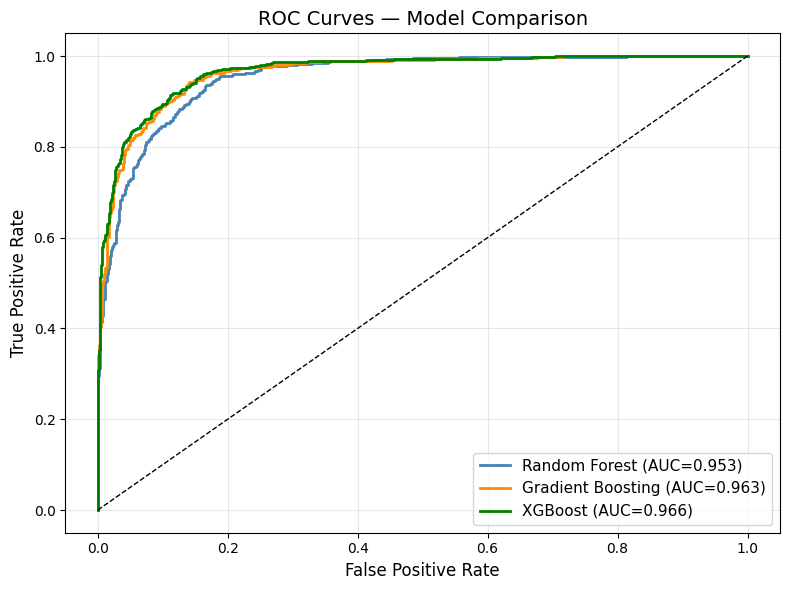

✅ roc_curves.png saved.


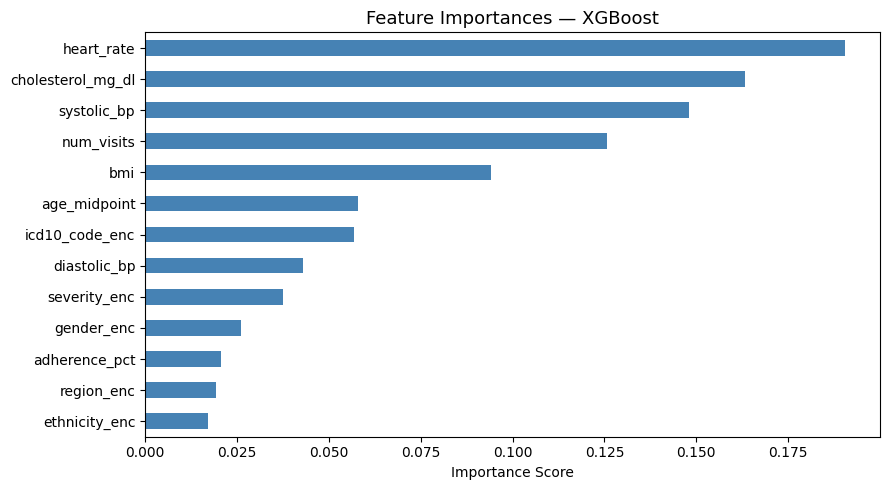

✅ feature_importance.png saved.


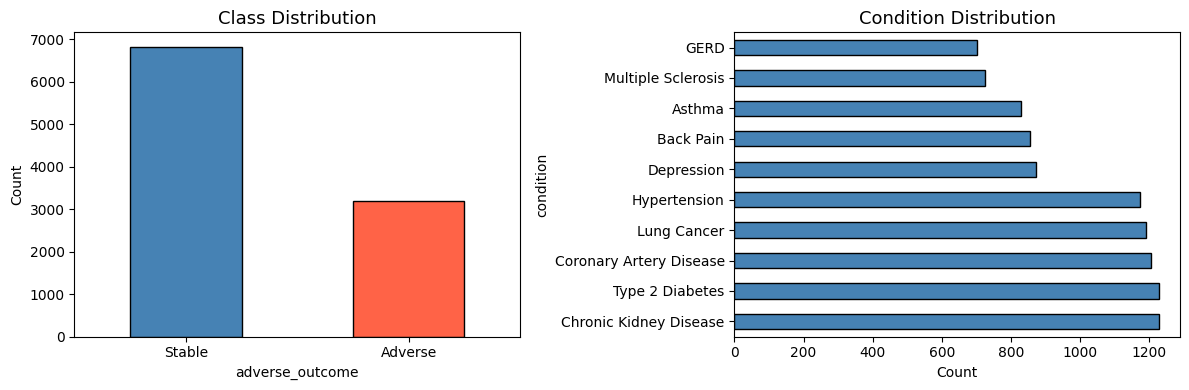

✅ data_distributions.png saved.


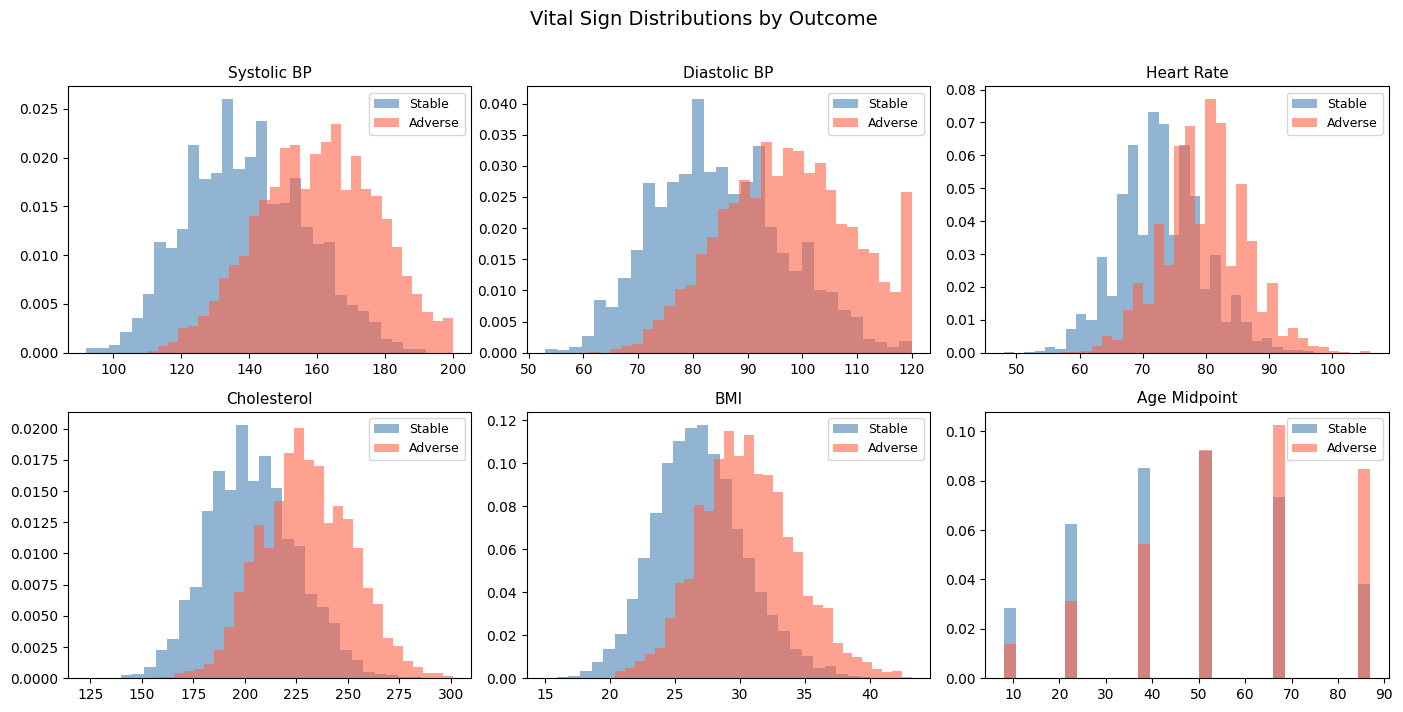

✅ vitals_distributions.png saved.


In [10]:
# ══════════════════════════════════════════════════════════════
# PART 8 — VISUALIZATIONS
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  PART 8 — VISUALIZATIONS")
print("=" * 55)

# Plot 1: ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue", "darkorange", "green"]
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, res["y_prob"])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Model Comparison", fontsize=14)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=120); plt.show()
print("✅ roc_curves.png saved.")

# Plot 2: Feature Importances
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=ALL_FEATS).sort_values()
    fig, ax = plt.subplots(figsize=(9,5))
    imp.tail(13).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Feature Importances — {best_name}", fontsize=13)
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=120); plt.show()
    print("✅ feature_importance.png saved.")

# Plot 3: Class & Condition Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["adverse_outcome"].value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue","tomato"], edgecolor="black")
axes[0].set_title("Class Distribution", fontsize=13)
axes[0].set_xticklabels(["Stable","Adverse"], rotation=0)
axes[0].set_ylabel("Count")
df["condition"].value_counts().plot(kind="barh", ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Condition Distribution", fontsize=13)
axes[1].set_xlabel("Count")
plt.tight_layout()
plt.savefig("data_distributions.png", dpi=120); plt.show()
print("✅ data_distributions.png saved.")

# Plot 4: Vitals by Outcome
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
vital_cols   = ["systolic_bp","diastolic_bp","heart_rate","cholesterol_mg_dl","bmi","age_midpoint"]
vital_labels = ["Systolic BP","Diastolic BP","Heart Rate","Cholesterol","BMI","Age Midpoint"]
for ax, col, label in zip(axes.flatten(), vital_cols, vital_labels):
    for outcome, color, lbl in [(0,"steelblue","Stable"),(1,"tomato","Adverse")]:
        df[df["adverse_outcome"]==outcome][col].plot(
            kind="hist", bins=30, alpha=0.6, ax=ax, color=color, label=lbl, density=True)
    ax.set_title(label, fontsize=11); ax.legend(fontsize=9); ax.set_ylabel("")
plt.suptitle("Vital Sign Distributions by Outcome", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("vitals_distributions.png", dpi=120); plt.show()
print("✅ vitals_distributions.png saved.")



  PART 9 — SHAP INTERPRETABILITY


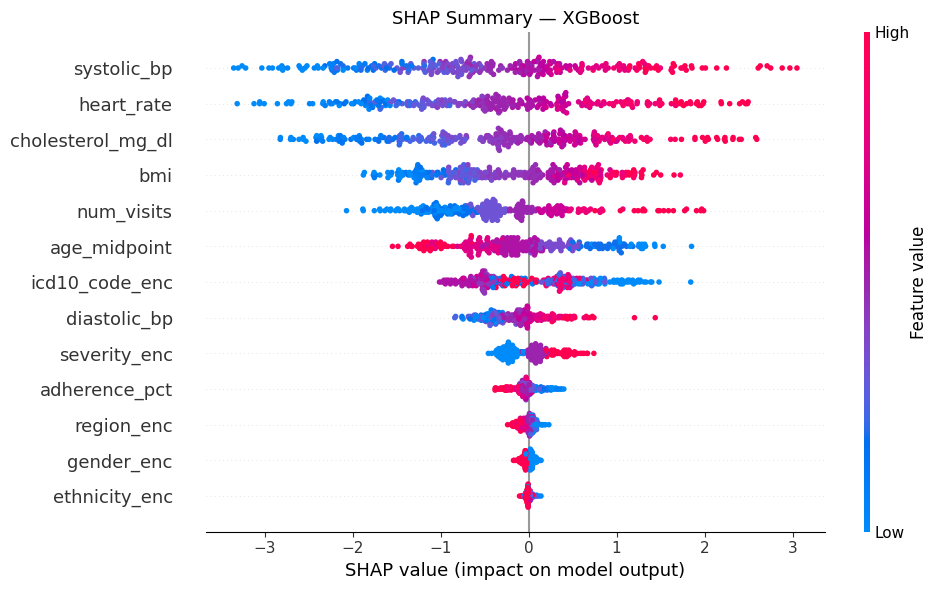

✅ shap_summary.png saved.


In [11]:
# ══════════════════════════════════════════════════════════════
# PART 9 — SHAP INTERPRETABILITY
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  PART 9 — SHAP INTERPRETABILITY")
print("=" * 55)

X_shap      = X_val.sample(300, random_state=42)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

sv = (shap_values[:,:,1] if isinstance(shap_values, np.ndarray) and shap_values.ndim==3
      else (shap_values[1] if isinstance(shap_values, list) else shap_values))

shap.summary_plot(sv, X_shap, feature_names=ALL_FEATS, show=False, plot_size=(10,6))
plt.title(f"SHAP Summary — {best_name}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=120, bbox_inches="tight"); plt.show()
print("✅ shap_summary.png saved.")


In [12]:
# ══════════════════════════════════════════════════════════════
# PART 10 — METADATA
# ══════════════════════════════════════════════════════════════
meta = {
    "dataset_name": "Synthetic Privacy-Preserving Medical Dataset v5",
    "records": N,
    "features": ALL_FEATS,
    "target": "adverse_outcome",
    "splits": {"train":"70%","val":"15%","test":"15%"},
    "privacy_techniques": [
        "UUID patient IDs — no real names",
        "Age buckets — no exact ages",
        "Region labels — no city/postcode",
        "Laplace differential privacy noise on vitals (epsilon=2)",
    ],
    "preprocessing": [
        "5% missing values simulated then imputed (median)",
        "StandardScaler on numerical features (fit on train only)",
        "LabelEncoder on categorical features",
        "SMOTE on training set only — no val/test leakage",
        "outcome column excluded from features — no target leakage",
    ],
    "models_trained": list(trained.keys()),
    "best_model": best_name,
    "best_val_roc_auc": round(float(results[best_name]["auc"]), 4),
    "best_rf_params": best_params,
}
with open("metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\n" + "=" * 55)
print("✅ PIPELINE COMPLETE v5 — All outputs saved:")
print("   full_dataset.csv | train.csv | val.csv | test.csv")
print("   metadata.json")
print("   roc_curves.png | feature_importance.png")
print("   data_distributions.png | vitals_distributions.png")
print("   shap_summary.png")
print("=" * 55)



✅ PIPELINE COMPLETE v5 — All outputs saved:
   full_dataset.csv | train.csv | val.csv | test.csv
   metadata.json
   roc_curves.png | feature_importance.png
   data_distributions.png | vitals_distributions.png
   shap_summary.png
